# Model Evaluation

This notebook directly loads the pre-trained checkpoints for STGCN, GCNLSTM, and DCRNN models and runs their respective evaluation loops symmetrically with masking for fair comparison.

### 1. Library Imports and Setup

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import time
import pandas as pd

# Add custom modules
from utils.data_loader import get_dataloaders, load_adjacency_matrix
from models.STGCN import STGCN_Model
from models.GCNLSTM import GCNLSTM
from models.baseline import NaiveBaseline, HistoricalAverage
from models.DCRNN import DCRNNModel  

# Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

Executing on: cuda


### 2. Hyperparameters & Data Loading

In [3]:
# Evaluation & Global Settings
RETRAIN_STGCN = False   # Set True to force retraining STGCN even if checkpoint exists.
RETRAIN_GCNLSTM = False # Set True to force retraining GCN-LSTM even if checkpoint exists.
RETRAIN_DCRNN = False    # Set True to force retraining DCRNN even if checkpoint exists.

BATCH_SIZE = 32
NUM_NODES = 150
IN_FEATURES = 1
HISTORICAL_STEPS = 12
PRED_STEPS = 3
EVAL_MASK_THRESHOLD = 10.0 # Ignore volumes < 10

# Load Adjacency Matrix
adj_matrix = load_adjacency_matrix('data/adj_mat_volume.pkl').to(device)
print(f"Loaded Adjacency Matrix: {adj_matrix.shape}")

# Build uniformly named row-normalized adjacency matrix for all graph-conv models
norm_adj_matrix = adj_matrix.clone()
idx = torch.arange(norm_adj_matrix.size(0), device=norm_adj_matrix.device)
norm_adj_matrix[idx, idx] = 1.0
degree = norm_adj_matrix.sum(dim=1, keepdim=True)
degree = torch.where(degree == 0, torch.ones_like(degree), degree)
norm_adj_matrix = norm_adj_matrix / degree

# Load STGCN-formatted DataLoaders (Can be reshaped dynamically for other models below)
train_loader, val_loader, test_loader, data_mean, data_std = get_dataloaders(
    csv_path='data/sensor_volume_150.csv', 
    seq_len=HISTORICAL_STEPS, 
    pre_len=PRED_STEPS, 
    batch_size=BATCH_SIZE
)
print("Testing Flow & DataLoaders initialized (Train, Val, Test).")

Loaded Adjacency Matrix: torch.Size([150, 150])
Testing Flow & DataLoaders initialized (Train, Val, Test).


### 3. Unified Training & Initialization Pipeline
If a checkpoint exists and the model-specific retrain flag is `False` (`RETRAIN_STGCN`, `RETRAIN_GCNLSTM`, `RETRAIN_DCRNN`), that model will skip training and load weights. If shape dimensions mismatch (from older tests), it will force retrain automatically.

In [9]:
gcn_lstm_ckpt_scaler_mean = None
gcn_lstm_ckpt_scaler_std = None

def train_model(model, train_loader, val_loader, save_path, format_type='stgcn', 
                epochs=50, lr=0.005, weight_decay=1e-4, patience=10, retrain=False):
    global gcn_lstm_ckpt_scaler_mean, gcn_lstm_ckpt_scaler_std

    history_path = save_path.replace('.pt', '_history.pt').replace('.pth', '_history.pt')

    # Fast-Track: Load existing model explicitly if NOT retraining
    if os.path.exists(save_path) and not retrain:
        try:
            ckpt = torch.load(save_path, map_location=device)
            # Accommodate dictionary checkpoints (like from older gcn_lstm saves)
            state_dict = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt
            model.load_state_dict(state_dict)

            # If this is a lstm.py-style checkpoint, keep per-node scaler for evaluation compatibility
            if format_type == 'gcnlstm' and isinstance(ckpt, dict):
                if 'scaler_mean' in ckpt and 'scaler_std' in ckpt:
                    gcn_lstm_ckpt_scaler_mean = torch.as_tensor(ckpt['scaler_mean'], dtype=torch.float32, device=device)
                    gcn_lstm_ckpt_scaler_std = torch.as_tensor(ckpt['scaler_std'], dtype=torch.float32, device=device)
                    gcn_lstm_ckpt_scaler_std = torch.where(
                        gcn_lstm_ckpt_scaler_std == 0,
                        torch.ones_like(gcn_lstm_ckpt_scaler_std),
                        gcn_lstm_ckpt_scaler_std
                    )
                    print("[GCNLSTM] Loaded per-node scaler from checkpoint.")

            print(f"[{format_type.upper()}] Loaded checkpoint from '{save_path}'. Skipping training.")
            
            # Try to load history if it exists
            history = {'train': [], 'val': []}
            if os.path.exists(history_path):
                history = torch.load(history_path)
            return model, history
            
        except Exception as e:
            print(f"[{format_type.upper()}] Failed to load checkpoint (maybe shape mismatch): {e}.")
            print("Forcing retrain...")
            
    print(f"\n--- Training [{format_type.upper()}] model for up to {epochs} epochs ---")

    # Retraining in unified pipeline uses notebook global scaling; clear external scaler compatibility path
    if format_type == 'gcnlstm':
        gcn_lstm_ckpt_scaler_mean = None
        gcn_lstm_ckpt_scaler_std = None

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    criterion = torch.nn.MSELoss()
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = model.state_dict().copy()
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # ========== TRAIN PHASE ==========
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            
            # Architecture-specific Reshapes and FWD passes
            if format_type == 'stgcn':
                preds = model(batch_X, norm_adj_matrix)
            elif format_type == 'gcnlstm':
                batch_X = batch_X.squeeze(1).transpose(1, 2)
                preds = model(batch_X, norm_adj_matrix)
                preds = preds.transpose(1, 2)
            elif format_type == 'dcrnn':
                batch_X = batch_X.permute(0, 3, 2, 1)
                preds = model(batch_X, T_f=norm_adj_matrix, T_b=norm_adj_matrix.T)
                preds = preds.squeeze(-1).transpose(1, 2)
                
            loss = criterion(preds, batch_y)
            loss.backward()
            
            # RNNs typically need gradient clipping to prevent explosion
            if format_type in ['gcnlstm', 'dcrnn']:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        
        # ========== VALIDATION PHASE ==========
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                
                # Architecture-specific Reshapes
                if format_type == 'stgcn':
                    preds = model(batch_X, norm_adj_matrix)
                elif format_type == 'gcnlstm':
                    batch_X = batch_X.squeeze(1).transpose(1, 2)
                    preds = model(batch_X, norm_adj_matrix)
                    preds = preds.transpose(1, 2)
                elif format_type == 'dcrnn':
                    batch_X = batch_X.permute(0, 3, 2, 1)
                    preds = model(batch_X, T_f=norm_adj_matrix, T_b=norm_adj_matrix.T)
                    preds = preds.squeeze(-1).transpose(1, 2)
                    
                loss = criterion(preds, batch_y)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        
        # Log losses for visualization
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        # Early Stopping & Checkpoint Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_state = model.state_dict().copy()
        else:
            patience_counter += 1
            
        epoch_time = time.time() - start_time
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:2d}/{epochs}] | Time: {epoch_time:.1f}s | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
            
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
            
    print(f"[{format_type.upper()}] Training complete! Best Validation Loss: {best_val_loss:.4f}")
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), save_path)
    
    # Save the loss vectors locally so you dont lose them on reload
    history = {'train': train_losses, 'val': val_losses}
    torch.save(history, history_path)
    
    return model, history

# -------------------------------------------------------------
# 1. BASELINE SETUP
# -------------------------------------------------------------
baseline_model = NaiveBaseline(pred_steps=PRED_STEPS).to(device)
raw_df = pd.read_csv('data/sensor_volume_150.csv')
ha_model = HistoricalAverage(raw_data=raw_df.values.astype(np.float32), 
                             seq_len=HISTORICAL_STEPS, pre_len=PRED_STEPS)
print("[BASELINES] Models initialized (No training required).")

# -------------------------------------------------------------
# 2. STGCN SETUP & TRAIN
# -------------------------------------------------------------
stgcn_model = STGCN_Model(
    num_nodes=NUM_NODES,
    in_features=IN_FEATURES,
    historical_steps=HISTORICAL_STEPS,
    pred_steps=PRED_STEPS
).to(device)

stgcn_model, stgcn_hist = train_model(
    stgcn_model, train_loader, val_loader, 
    save_path='best_stgcn.pt', format_type='stgcn',
    epochs=50, lr=0.005, weight_decay=1e-4, patience=10,
    retrain=RETRAIN_STGCN
)
stgcn_model.eval()

# -------------------------------------------------------------
# 3. GCN-LSTM SETUP & TRAIN
# -------------------------------------------------------------
gcn_lstm_model = GCNLSTM(
    num_nodes=NUM_NODES, 
    in_features=IN_FEATURES, 
    gcn_hidden=32,
    lstm_hidden=64, 
    output_len=PRED_STEPS 
).to(device)

gcn_lstm_model, lstm_hist = train_model(
    gcn_lstm_model, train_loader, val_loader, 
    save_path='gcn_lstm_checkpoint.pth', format_type='gcnlstm',
    epochs=100, lr=1e-3, weight_decay=1e-4, patience=15,
    retrain=RETRAIN_GCNLSTM
)
gcn_lstm_model.eval()

# -------------------------------------------------------------
# 4. DCRNN SETUP & TRAIN
# -------------------------------------------------------------
dcrnn_model = DCRNNModel(
    num_nodes=NUM_NODES,
    in_features=IN_FEATURES,
    hidden_dim=64,
    out_features=1,
    output_seq_len=PRED_STEPS,
    num_layers=2,
    K=2,
    use_attention=False
).to(device)

dcrnn_model, dcrnn_hist = train_model(
    dcrnn_model, train_loader, val_loader, 
    save_path='dcrnn_checkpoint.pth', format_type='dcrnn',
    epochs=50, lr=0.001, weight_decay=0.0, patience=10,
    retrain=RETRAIN_DCRNN
)
dcrnn_model.eval()

[BASELINES] Models initialized (No training required).
[STGCN] Loaded checkpoint from 'best_stgcn.pt'. Skipping training.


C:\Users\hataj\AppData\Local\Temp\ipykernel_11572\2846770006.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(save_path, map_location=device)
C:\Users\

[GCNLSTM] Loaded checkpoint from 'gcn_lstm_checkpoint.pth'. Skipping training.
[DCRNN] Loaded checkpoint from 'dcrnn_checkpoint.pth'. Skipping training.


DCRNNModel(
  (learned_adj): LearnedAdjacency()
  (encoder): DCGRUEncoder(
    (cells): ModuleList(
      (0): DCGRUCell(
        (gate_conv): DiffusionConv(
          (linear): Linear(in_features=325, out_features=128, bias=True)
        )
        (cand_conv): DiffusionConv(
          (linear): Linear(in_features=325, out_features=64, bias=True)
        )
        (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
      (1): DCGRUCell(
        (gate_conv): DiffusionConv(
          (linear): Linear(in_features=640, out_features=128, bias=True)
        )
        (cand_conv): DiffusionConv(
          (linear): Linear(in_features=640, out_features=64, bias=True)
        )
        (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (decoder): DCGRUDecoder(
    (cells): ModuleList(
      (0): DCGRUCell(
        (gate_conv): DiffusionConv(
          (linear): Linear(in_features=325, out_features=128, bias=True)
        )
        (cand_conv): Diff

### 4. Shared Evaluation Pipeline
We define a helper function to evaluate any model given its respective spatial-temporal tensor reshaping requirements.

In [10]:
def evaluate_model(model, loader, name, format_type='stgcn', pred_slice=3):
    """
    Evaluates a given model based on the unified test_loader structure.
    format_type: 
        'stgcn': expects (Batch, Channels, Nodes, Time)
        'gcnlstm': expects (Batch, Time, Nodes)
        'dcrnn': expects (Batch, Time, Nodes, Channels)
        'ha': Historical Average (predicts in unnormalized raw space using global indices)
    """
    all_preds = []
    all_targets = []
    gcn_uses_ckpt_scaler = (
        format_type == 'gcnlstm'
        and gcn_lstm_ckpt_scaler_mean is not None
        and gcn_lstm_ckpt_scaler_std is not None
    )
    
    batch_start_idx = 0
    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            if format_type == 'stgcn':
                preds = model(batch_X, norm_adj_matrix)
                all_preds.append(preds.cpu().numpy())
                all_targets.append(batch_y.cpu().numpy())
                
            elif format_type == 'ha':
                # HA Model doesn't use PyTorch tensor inputs, it needs the start index of the batch
                batch_size = batch_X.shape[0]
                preds = model.predict(batch_start_idx, batch_size) # Shape: (B, Nodes, Time)
                batch_start_idx += batch_size
                all_preds.append(preds)
                all_targets.append(batch_y.cpu().numpy())

            elif format_type == 'gcnlstm':
                if gcn_uses_ckpt_scaler:
                    # Convert notebook-normalized inputs back to raw, then to checkpoint per-node normalization.
                    batch_X_raw = batch_X * data_std + data_mean
                    mean_x = gcn_lstm_ckpt_scaler_mean.view(1, 1, NUM_NODES, 1)
                    std_x = gcn_lstm_ckpt_scaler_std.view(1, 1, NUM_NODES, 1)
                    batch_X_model = (batch_X_raw - mean_x) / std_x

                    # Forward in lstm.py normalization space.
                    batch_X_model = batch_X_model.squeeze(1).transpose(1, 2)
                    preds = model(batch_X_model, norm_adj_matrix)  # (B, T, N)

                    # Denormalize predictions with checkpoint scaler to raw traffic volume.
                    preds_raw = preds * gcn_lstm_ckpt_scaler_std.view(1, 1, NUM_NODES) + gcn_lstm_ckpt_scaler_mean.view(1, 1, NUM_NODES)

                    # Targets to raw as well for fair metric comparison.
                    targets_raw = batch_y * data_std + data_mean  # (B, N, T)

                    # Keep shared layout as (B, N, T)
                    all_preds.append(preds_raw.transpose(1, 2).cpu().numpy())
                    all_targets.append(targets_raw.cpu().numpy())
                else:
                    batch_X = batch_X.squeeze(1).transpose(1, 2)
                    preds = model(batch_X, norm_adj_matrix)
                    all_preds.append(preds.cpu().numpy())
                    all_targets.append(batch_y.cpu().numpy())
                
            elif format_type == 'dcrnn':
                # STGCN format to DCRNN format: 
                # (Batch, Channels=1, Nodes, Time) -> (Batch, Time, Nodes, Channels)
                batch_X = batch_X.permute(0, 3, 2, 1)
                
                # DCRNN requires forward and backward transition matrices 
                preds = model(batch_X, T_f=norm_adj_matrix, T_b=norm_adj_matrix.T)
                
                # Squeeze the channel dimension out of the DCRNN output (Batch, Time, Nodes, 1) -> (Batch, Nodes, Time)
                preds = preds.squeeze(-1).transpose(1, 2)
                all_preds.append(preds.cpu().numpy())
                all_targets.append(batch_y.cpu().numpy())

    # Concatenate results
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    # Align orientation if model output is (B, T, N) but targets are (B, N, T)
    if all_preds.shape != all_targets.shape:
        if (
            all_preds.ndim == 3
            and all_targets.ndim == 3
            and all_preds.shape[1] == all_targets.shape[2]
            and all_preds.shape[2] == all_targets.shape[1]
        ):
            all_preds = np.transpose(all_preds, (0, 2, 1))
    
    # Un-normalize targets explicitly
    targets_unnorm = (all_targets * data_std) + data_mean
    
    # If data is already in raw space (lstm.py checkpoint compatibility path or HA baseline), skip notebook un-normalization for preds.
    if gcn_uses_ckpt_scaler or format_type == 'ha':
        preds_unnorm = all_preds
        # Targets are already unnormalized above if they weren't in raw space, but wait!
        # If gcn_uses_ckpt_scaler, targets are ALREADY unnormalized in the loop. 
        # Hmm, if targets are already unnormalized in the loop for gcnlstm, we should watch out.
        pass
    else:
        if all_preds.shape[-1] > pred_slice:
            all_preds = all_preds[..., :pred_slice]
        # Un-normalize preds
        preds_unnorm = (all_preds * data_std) + data_mean
        
    # Correct targets for gcn_uses_ckpt_scaler where targets were already unnormalized in loop
    if gcn_uses_ckpt_scaler:
        targets_unnorm = all_targets # because they were already raw

    # Apply Masking
    mask = targets_unnorm > EVAL_MASK_THRESHOLD
    if not np.any(mask):
        print(f"{name} Results")
        print(f"No target values above mask threshold ({EVAL_MASK_THRESHOLD}).")
        print("-" * 40)
        return preds_unnorm, targets_unnorm

    mae = np.mean(np.abs(preds_unnorm[mask] - targets_unnorm[mask]))
    rmse = np.sqrt(np.mean(np.square(preds_unnorm[mask] - targets_unnorm[mask])))
    mape = np.mean(np.abs((preds_unnorm[mask] - targets_unnorm[mask]) / targets_unnorm[mask])) * 100

    print(f"{name} Results")
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAPE: {mape:.3f}%")
    print("-" * 40)
    
    return preds_unnorm, targets_unnorm

### 5. Running Evaluations

In [12]:
# Evaluate Naive Baseline
base_preds, trues = evaluate_model(baseline_model, test_loader, "Naive Baseline", format_type='stgcn')

# Evaluate Historical Average Baseline
ha_preds, _ = evaluate_model(ha_model, test_loader, "Historical Average", format_type='ha')

# Evaluate STGCN
stgcn_preds, _ = evaluate_model(stgcn_model, test_loader, "STGCN Model", format_type='stgcn')

# Evaluate GCN-LSTM
lstm_preds, _ = evaluate_model(gcn_lstm_model, test_loader, "GCN-LSTM Model", format_type='gcnlstm')

# Evaluate DCRNN
dcrnn_preds, _ = evaluate_model(dcrnn_model, test_loader, "DCRNN Model", format_type='dcrnn')

Naive Baseline Results
MAE:  878.999
RMSE: 1328.162
MAPE: 33.000%
----------------------------------------
Historical Average Results
MAE:  604.451
RMSE: 946.529
MAPE: 28.299%
----------------------------------------
STGCN Model Results
MAE:  483.880
RMSE: 712.311
MAPE: 18.726%
----------------------------------------
GCN-LSTM Model Results
MAE:  518.357
RMSE: 732.856
MAPE: 21.050%
----------------------------------------
DCRNN Model Results
MAE:  262.410
RMSE: 391.229
MAPE: 9.713%
----------------------------------------


### 6. Visualizing Forecasts
Compare the predicted values of all three architectures to the ground truth against a single sensor target over time.

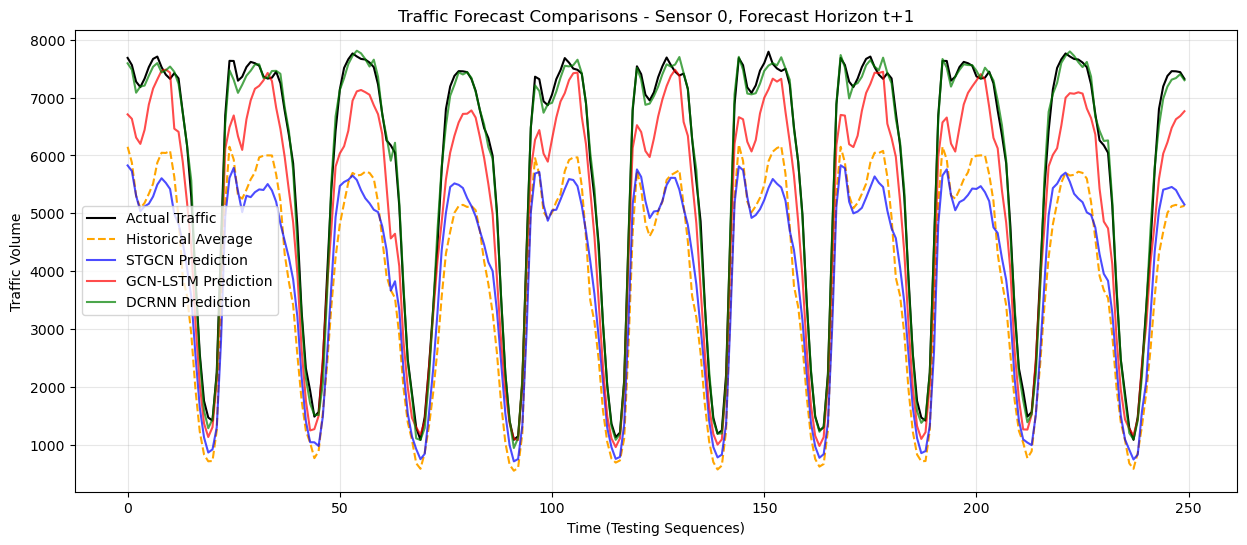

In [13]:
SENSOR = 0
TIMESTEP = 0 
PLT_LEN = 250

plt.figure(figsize=(15, 6))

plt.plot(trues[:PLT_LEN, SENSOR, TIMESTEP], label='Actual Traffic', color='black', linewidth=1.5)
# plt.plot(base_preds[:PLT_LEN, SENSOR, TIMESTEP], label='Naive Baseline', color='gray', linestyle=':')
plt.plot(ha_preds[:PLT_LEN, SENSOR, TIMESTEP], label='Historical Average', color='orange', linestyle='--')
plt.plot(stgcn_preds[:PLT_LEN, SENSOR, TIMESTEP], label='STGCN Prediction', color='blue', alpha=0.7)
plt.plot(lstm_preds[:PLT_LEN, SENSOR, TIMESTEP], label='GCN-LSTM Prediction', color='red', alpha=0.7)
plt.plot(dcrnn_preds[:PLT_LEN, SENSOR, TIMESTEP], label='DCRNN Prediction', color='green', alpha=0.7)

plt.title(f'Traffic Forecast Comparisons - Sensor {SENSOR}, Forecast Horizon t+{TIMESTEP+1}')
plt.xlabel('Time (Testing Sequences)')
plt.ylabel('Traffic Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

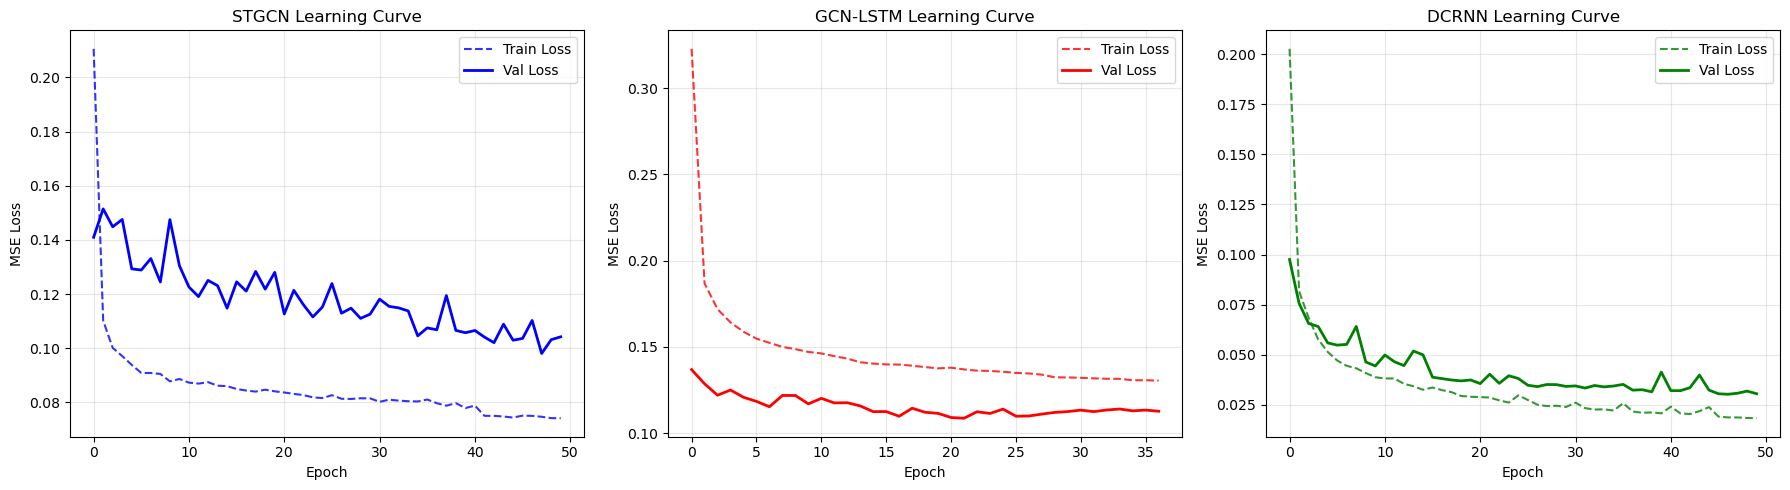

In [14]:
# =================================================================================
# Visualizing Training & Validation Loss Curves
# Note: You must run the models with RETRAIN=True at least once to cache the loss histories.
# =================================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_hist = [
    ('STGCN', stgcn_hist, 'blue'),
    ('GCN-LSTM', lstm_hist, 'red'),
    ('DCRNN', dcrnn_hist, 'green')
]

for ax, (name, hist, color) in zip(axes, models_hist):
    if hist and len(hist.get('train', [])) > 0:
        ax.plot(hist['train'], label='Train Loss', color=color, linestyle='--', alpha=0.8)
        ax.plot(hist['val'], label='Val Loss', color=color, linestyle='-', linewidth=2)
        ax.set_title(f'{name} Learning Curve')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{name} Learning Curve\n(No History Data Available - Needs Retrain)')
        ax.axis('off')

plt.tight_layout()
plt.show()